Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

Data collection and analysis

In [2]:
df = pd.read_csv('D:\\my python projects\\nifty-50\\RELIANCE.csv')
print(df.head())



         Date    Symbol Series  Prev Close    Open    High     Low    Last  \
0  2000-01-03  RELIANCE     EQ      233.05  237.50  251.70  237.50  251.70   
1  2000-01-04  RELIANCE     EQ      251.70  258.40  271.85  251.30  271.85   
2  2000-01-05  RELIANCE     EQ      271.85  256.65  287.90  256.65  286.75   
3  2000-01-06  RELIANCE     EQ      282.50  289.00  300.70  289.00  293.50   
4  2000-01-07  RELIANCE     EQ      294.35  295.00  317.90  293.00  314.50   

    Close    VWAP    Volume      Turnover  Trades  Deliverable Volume  \
0  251.70  249.37   4456424  1.111319e+14     NaN                 NaN   
1  271.85  263.52   9487878  2.500222e+14     NaN                 NaN   
2  282.50  274.79  26833684  7.373697e+14     NaN                 NaN   
3  294.35  295.45  15682286  4.633254e+14     NaN                 NaN   
4  314.55  308.91  19870977  6.138388e+14     NaN                 NaN   

   %Deliverble  
0          NaN  
1          NaN  
2          NaN  
3          NaN  
4      

In [3]:
stock_dataset=df.copy()
stock_dataset.shape

(5306, 15)

In [4]:
stock_dataset.describe()

,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
count,5306.000000,5306.000000,5306.000000,5306.000000,5306.000000,5306.000000,5306.000000,5.306000e+03,5.306000e+03,2.456000e+03,4.792000e+03,4792.000000
mean,1010.984866,1012.602375,1026.823803,996.886977,1011.157143,1011.316839,1011.937409,5.583028e+06,6.076715e+14,1.452306e+05,2.280885e+06,0.435039
std,570.987079,572.575893,581.986757,560.703328,570.938608,571.046753,571.222520,4.983793e+06,8.369739e+14,1.297557e+05,1.882665e+06,0.144722
min,203.200000,205.500000,219.500000,197.150000,203.300000,203.200000,212.290000,5.282000e+04,4.295543e+12,2.991000e+03,2.909700e+04,0.076300
25%,572.137500,572.925000,582.950000,564.237500,572.062500,572.512500,573.190000,2.836454e+06,2.203354e+14,7.215900e+04,1.194524e+06,0.323325
50%,937.950000,939.000000,950.075000,927.550000,939.025000,938.275000,939.785000,4.213432e+06,3.662999e+14,1.021435e+05,1.810434e+06,0.449450
75%,1247.387500,1247.675000,1267.350000,1227.450000,1248.287500,1248.275000,1247.375000,6.602604e+06,6.656490e+14,1.686702e+05,2.752935e+06,0.544300
max,3220.850000,3298.000000,3298.000000,3141.300000,3223.000000,3220.850000,3197.750000,6.523089e+07,1.473434e+16,1.428490e+06,3.495888e+07,0.978300


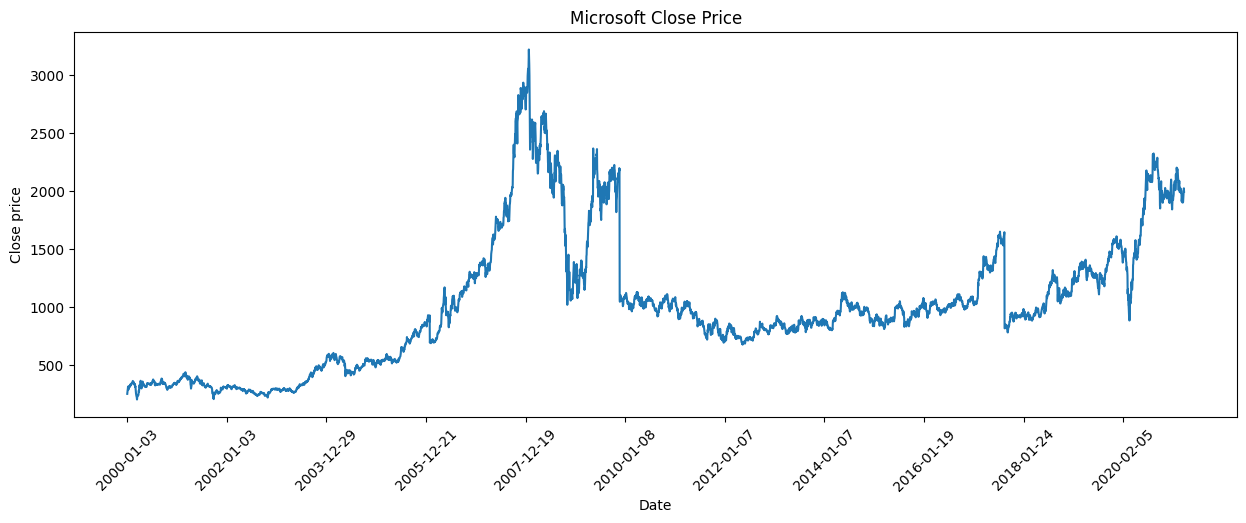

In [5]:
#plotting close price
plt.figure(figsize=(15,5))
plt.plot(stock_dataset['Date'],stock_dataset['Close'])
plt.xticks(range(0,stock_dataset.shape[0],500),stock_dataset['Date'].loc[::500],rotation=45)
plt.title('Microsoft Close Price')
plt.ylabel('Close price')
plt.xlabel('Date')
plt.show()


Data Preprocessing

In [6]:
# Use the 'Close' column for prediction
close=stock_dataset[['Close']].values
# Scale the data to be between 0 and 1
scaler = MinMaxScaler(feature_range=(0,1))
scaled_close = scaler.fit_transform(close)
print(scaled_close)

[[0.01607211]
 [0.02274949]
 [0.02627873]
 ...
 [0.59453548]
 [0.6034    ]
 [0.59360761]]


In [7]:
# Prepare dataset
def create_dataset(dataset, timestep=1):
  X,Y=[],[]
  for i in range(len(dataset)-timestep-1):
    a=dataset[i:(i+timestep),0]
    X.append(a)
    Y.append(dataset[i+timestep,0])
  return np.array(X),np.array(Y)


In [8]:
timestep=60

In [9]:
X,Y=create_dataset(scaled_close,timestep)
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.3,shuffle=False)

In [10]:
X_train=X_train.reshape(X_train.shape[0],X_train.shape[1],1)
X_test=X_test.reshape(X_test.shape[0],X_test.shape[1],1)

Building LSTM model

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense

In [12]:
model=Sequential()
model.add(LSTM(50,return_sequences=True,input_shape=(timestep,1)))
model.add(Dropout(0.2))
model.add(LSTM(units=50,return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(units=50,return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(units=50))
model.add(Dropout(0.2))
model.add(Dense(units=1))

C:\Users\hp\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
model.compile(optimizer='adam',loss='mean_squared_error')
model.fit(X_train,Y_train,epochs=100,batch_size=32)

Epoch 1/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 14s 69ms/step - loss: 0.0183
Epoch 2/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 8s 68ms/step - loss: 0.0022
Epoch 3/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 10s 82ms/step - loss: 0.0019
Epoch 4/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 9s 76ms/step - loss: 0.0018
Epoch 5/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 10s 85ms/step - loss: 0.0019
Epoch 6/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step - loss: 0.0018
Epoch 7/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step - loss: 0.0018
Epoch 8/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 8s 72ms/step - loss: 0.0015
Epoch 9/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step - loss: 0.0011
Epoch 10/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 8s 71ms/step - loss: 0.0020
Epoch 11/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step - loss: 0.0013
Epoch 12/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step - loss: 0.0013
Epoch 13/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step - loss: 0.0014
Epoch 14/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step - loss: 0.0012
Epoch 15/100
115/115 ━━━━━

In [14]:
train_predict=model.predict(X_train)
test_predict=model.predict(X_test)

115/115 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step


In [15]:
train_predict=scaler.inverse_transform(train_predict)
test_predict=scaler.inverse_transform(test_predict)

In [16]:
Y_train=scaler.inverse_transform([Y_train])
Y_test=scaler.inverse_transform([Y_test])

In [17]:
train_size=len(train_predict)
test_size=len(test_predict)
train_index=np.arange(timestep,train_size+timestep)
test_index=np.arange(train_size+(timestep*2),train_size+(timestep*2)+test_size)
train_index = train_index[train_index < len(stock_dataset)]
test_index = test_index[test_index < len(stock_dataset)]
# Ensure the lengths of the predictions match the indices
train_predict = train_predict[:len(train_index)]
test_predict = test_predict[:len(test_index)]

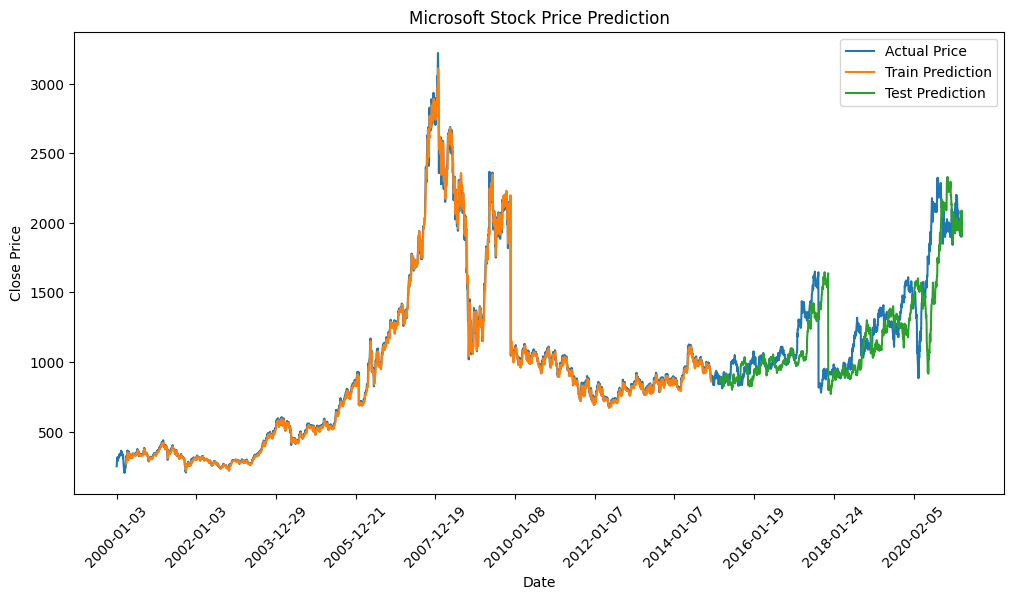

In [18]:
plt.figure(figsize=(12, 6))
plt.plot(stock_dataset['Date'], close, label='Actual Price')
plt.plot(stock_dataset['Date'].iloc[train_index], train_predict, label='Train Prediction')
plt.plot(stock_dataset['Date'].iloc[test_index], test_predict, label='Test Prediction')
plt.xticks(range(0,stock_dataset.shape[0],500),stock_dataset['Date'].loc[::500],rotation=45)
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('Microsoft Stock Price Prediction')
plt.legend()
plt.show()